In [34]:
import numpy as np
import pandas as pd

from utils import validate, package_run_data, package_calib_data, circdist, circmedian
from tqdm import tqdm
import pickle

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import seaborn as sns
import arviz as az
import colorsys

# Math imports
import math
from functools import partial
from itertools import count
import numpy as np
from scipy.stats import norm, poisson, expon, uniform, binom, beta, halfnorm, multivariate_normal
import jax.numpy as jnp
import jax.random as jr
from jax import vmap
import jax
import optax

# Global flag to set a specific platform, must be used at startup.
jax.config.update('jax_platform_name', 'cpu')

from dynamax.hidden_markov_model import GaussianHMM, DiagonalGaussianHMM, LinearRegressionHMM
from dynamax.utils.utils import find_permutation

#NP set random seed
np.random.seed(42)

az.style.use("arviz-docgrid")

from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

cpu


## Loading data

In [3]:
experiment_orientations = [159, 123, 87, 51, 15]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

In [4]:
# Allow negative angles in calibration
c_table, med, std, ctimetable = package_calib_data(do_clip=False)
r_table, (x, y, d, r, e) = package_run_data(med, std, do_clip=False, do_noise_thresh=False)

Loading data: 100%|██████████| 288/288 [00:00<00:00, 309.92it/s]


## Formatting data for models

In [5]:
xaxis = np.arange(-250, 750, 1) * (1000/120)
start_idx, end_idx = np.searchsorted(xaxis, -500), np.searchsorted(xaxis, 1500)
mini_xaxis = xaxis[start_idx:end_idx]
(start_idx, end_idx)

(191, 430)

In [6]:
# our frmes of intrest are only
er = e[:, :, :, :, start_idx:end_idx].reshape(-1, 239)
ds = d[:, :, :, :, start_idx:end_idx].reshape(-1, 239)

er[np.isnan(er)] = 90
ds[np.isnan(ds)] = 0

er.shape, np.isnan(er).any(), ds.shape, np.isnan(ds).any(), ds.max(), ds.min(), er.max(), er.min()

((34560, 239), False, (34560, 239), False, 1.0, 0.0, 179.99928775789328, 0.0)

In [7]:
# min max scale err
er = er / 180

train_emissions = jnp.array(np.stack([ds, er], axis=-1))
train_emissions.shape

(34560, 239, 2)

## GLOBAL MODEL

In [8]:
with open("hmm_caches/global_init_params_2_states.pkl", "rb") as f:
    global_init = pickle.load(f)

In [9]:
global_init

ParamsGaussianHMM(initial=ParamsStandardHMMInitialState(probs=Array([0.96720254, 0.03279735], dtype=float32)), transitions=ParamsStandardHMMTransitions(transition_matrix=Array([[0.994412  , 0.00558809],
       [0.00864948, 0.9913505 ]], dtype=float32)), emissions=ParamsGaussianHMMEmissions(means=Array([[0.08588442, 0.3640902 ],
       [0.7501884 , 0.24068972]], dtype=float32), covs=Array([[[ 0.00285924,  0.00082319],
        [ 0.00082319,  0.06506077]],

       [[ 0.07698141, -0.00261457],
        [-0.00261457,  0.05046049]]], dtype=float32)))

## Full train 2 states Subject model

In [10]:
def train_gaussian_hmm(
        train_emissions, 
        pretrained_params = False, 
        em = True, 
        emission_dim = 2
        ):

    def clean_init(train_emissions, emission_dim = 2):
        # Initialize the parameters using K-Means on the full training set
        key = jr.PRNGKey(0)
        hmm = GaussianHMM(num_states=2, emission_dim=emission_dim, transition_matrix_stickiness=10.)
        params, props = hmm.initialize(key=key, method="kmeans", emissions=train_emissions)
        return params, props, hmm

    def fine_init(pretrained_params, emission_dim = 2):
        initial_probs = pretrained_params.initial.probs
        transition_matrix = pretrained_params.transitions.transition_matrix
        emission_means = pretrained_params.emissions.means
        emission_covs = pretrained_params.emissions.covs

        hmm = GaussianHMM(num_states=2, emission_dim=emission_dim)
        params, props = hmm.initialize(
            initial_probs= jnp.array(initial_probs),
            transition_matrix= jnp.array(transition_matrix),
            emission_means= jnp.array(emission_means),
            emission_covariances= jnp.array(emission_covs),
        )
        return params, props, hmm
    
    if pretrained_params:
        params, props, hmm = fine_init(pretrained_params, emission_dim)
    else:
        params, props, hmm = clean_init(train_emissions, emission_dim)
    
    if em:
        params, lps = hmm.fit_em(params, props, train_emissions, num_iters=100)
    else:
        params, lps = hmm.fit_sgd(
            params, props, train_emissions,
            num_epochs = 100, 
            optimizer = optax.adam(1e-4), 
            shuffle = True, 
            batch_size = 32,
        )
    
    return params, lps, hmm


In [11]:
# Splitting the training data for individual subjects
# Data should be in format (subjects, sessions, blocks, trials, timepoints)

s_params, s_lps, s_hmms = [], [], []

for subject_data in train_emissions.reshape(12, -1, 239, 2):
    params, lps, hmm = train_gaussian_hmm(subject_data, pretrained_params=global_init, em=True, emission_dim=2)
    s_params.append(params)
    s_lps.append(lps)
    s_hmms.append(hmm)

In [12]:
# store the trained params
# with open("hmm_caches/subject_init_params_2_states.pkl", "wb") as f:
#     pickle.dump(s_params, f)

### Visualizing subject trianing log probabilities

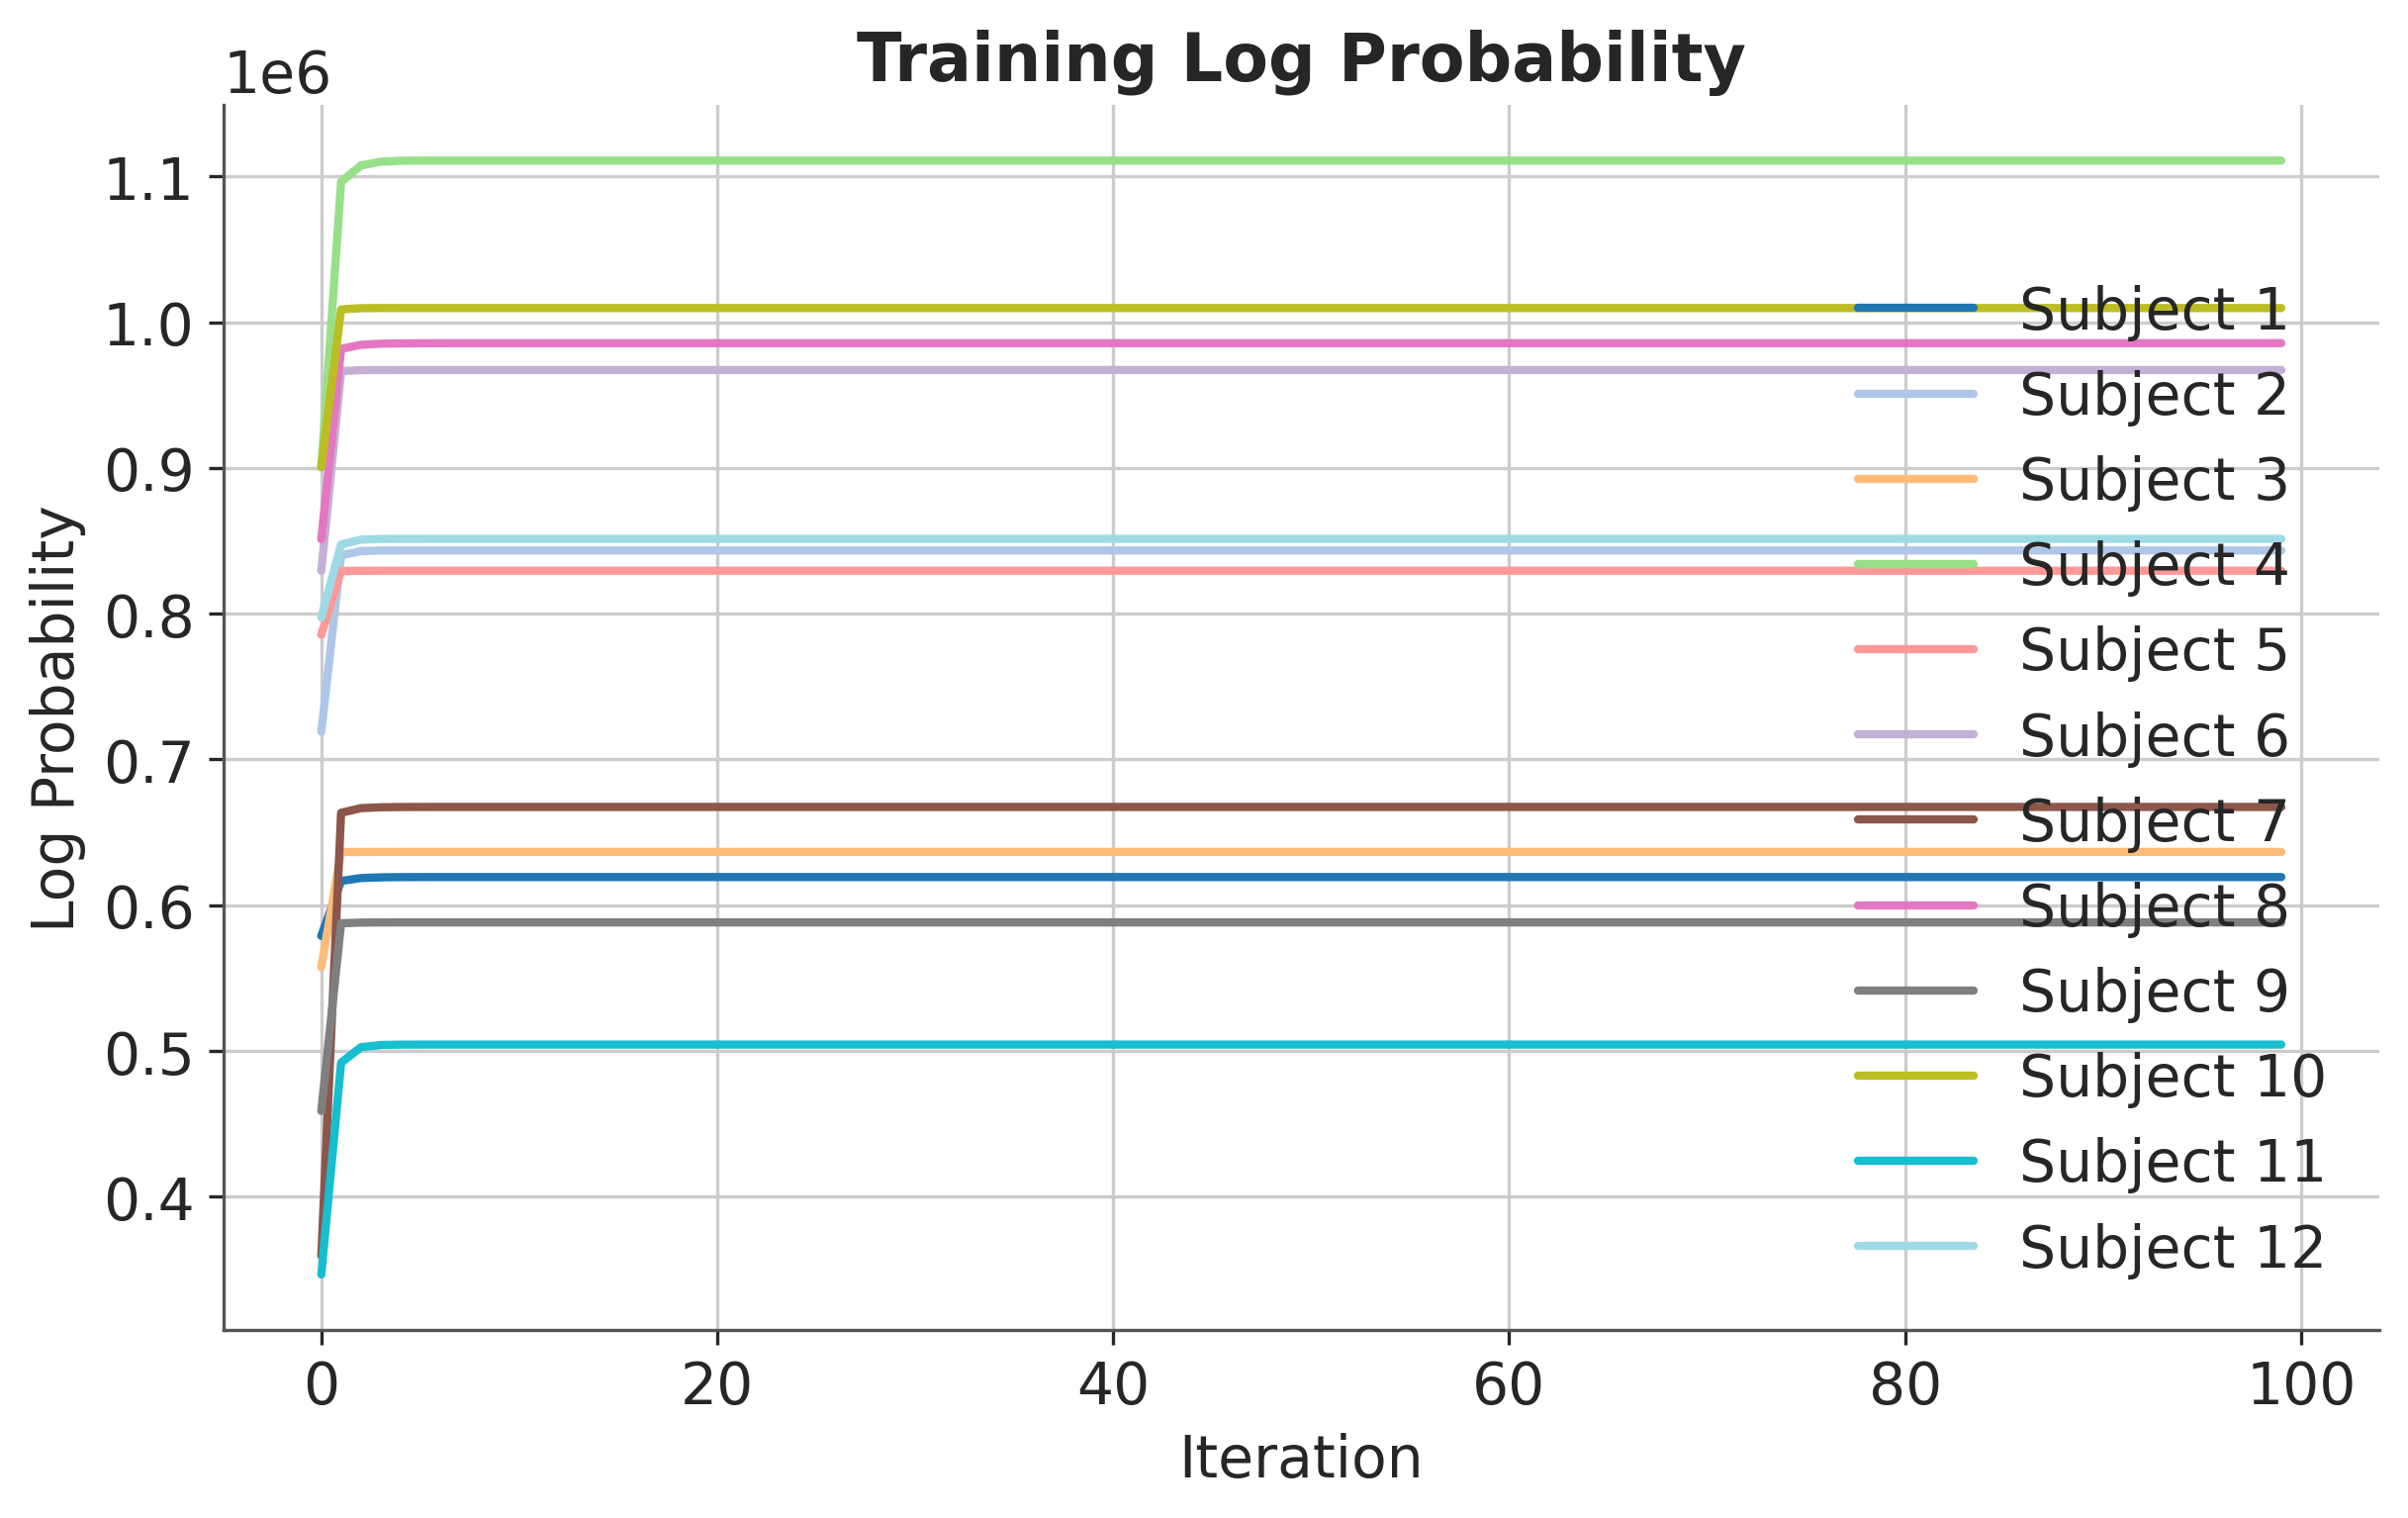

In [33]:
plt.figure(figsize=(8, 5))
tab20 = plt.get_cmap('tab20', len(s_lps))  # Get the tab20 colormap with the number of subjects
for i, lps in enumerate(s_lps):
    plt.plot(lps, label=f"Subject {i+1}", color=tab20(i), linewidth=2)  # Use a color from tab20
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Log Probability")
plt.title("Training Log Probability")
plt.show()

### Visaualizing subject state weights

In [78]:
# Data: Means and Covariances
def viz_gauss_params(means, covs, ax, title=""):

    # Generate a grid for plotting
    x, y = np.linspace(-0.2, 1.2, 500), np.linspace(-0.2, 1.2, 500)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))

    # Compute Gaussian densities
    rv1 = multivariate_normal(mean=means[0], cov=covs[0])
    rv2 = multivariate_normal(mean=means[1], cov=covs[1])
    Z1 = rv1.pdf(pos)
    Z2 = rv2.pdf(pos)

    # Heatmaps
    ax.contourf(X, Y, Z1, levels=50, cmap="Blues", alpha=0.3)
    ax.contourf(X, Y, Z2, levels=50, cmap="Reds", alpha=0.3)

    # Contour lines
    ax.contour(X, Y, Z1, levels=10, colors='blue', linewidths=.6, alpha=0.8)
    ax.contour(X, Y, Z2, levels=10, colors='red', linewidths=.6, alpha=0.8)

    # Scatter points for means with distinct labels
    ax.scatter(means[0, 0], means[0, 1], c='blue', s=100, marker="x", label='rest state mean')
    ax.scatter(means[1, 0], means[1, 1], c='red', s=100, marker="x", label='response state mean')
    
    # Labels and legend
    ax.set_title(title)

    ax.set_ylim(0,1)
    ax.set_xlim(0,1)

    # Apply y-ticks formatting similar to the plt.yticks() example
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([f"{int(y*180)}" for y in ax.get_yticks()])  # Format y-tick labels

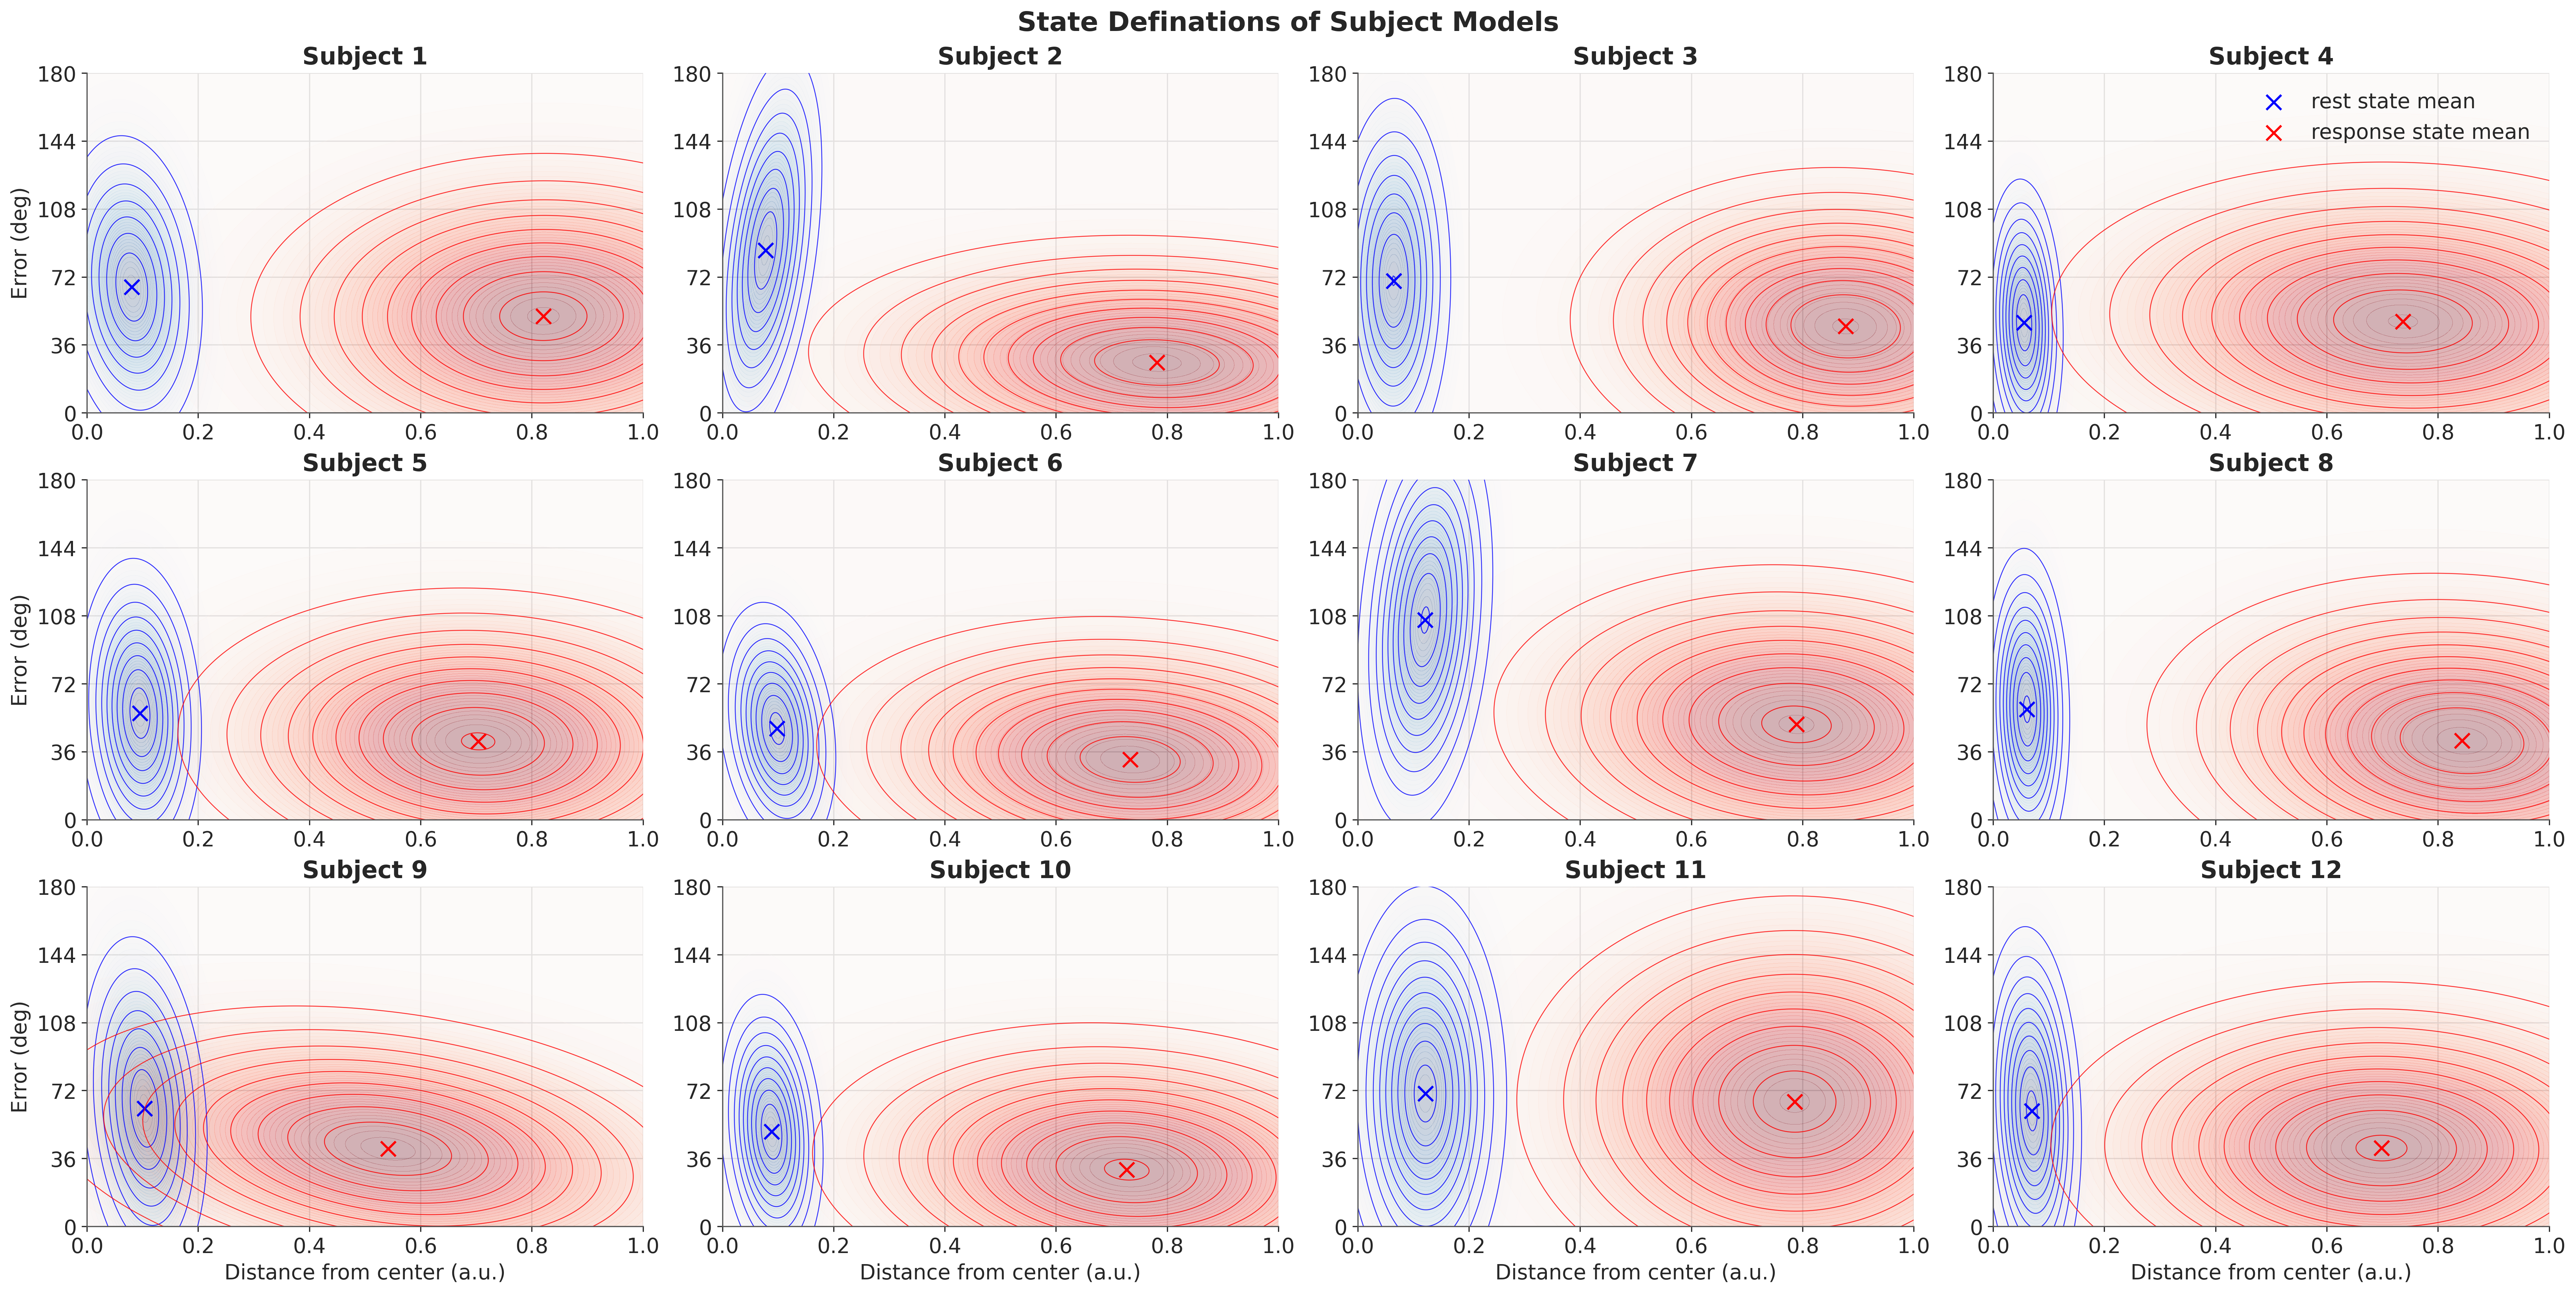

In [89]:
fig, ax = plt.subplots(3, 4, figsize=(6*4, 4*3))
for idx, s_par in enumerate(s_params):
    m = s_par.emissions.means
    c = s_par.emissions.covs
    viz_gauss_params(m, c, ax.flatten()[idx], title = f"Subject {idx+1}")

for a in ax[:, 0].flatten():
    a.set_ylabel("Error (deg)")

for a in ax[2,:].flatten():
    a.set_xlabel("Distance from center (a.u.)")

ax[0,3].legend(loc='upper right')
plt.suptitle("State Definations of Subject Models")
plt.show()